import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

In [3]:
df = pd.read_csv("netflix_titles.csv")

In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.shape

(8807, 12)

In [6]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Dick Johnson Is Dead,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [10]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

director        29.908028
country          9.435676
cast             9.367549
date_added       0.113546
rating           0.045418
duration         0.034064
show_id          0.000000
type             0.000000
title            0.000000
release_year     0.000000
listed_in        0.000000
description      0.000000
dtype: float64

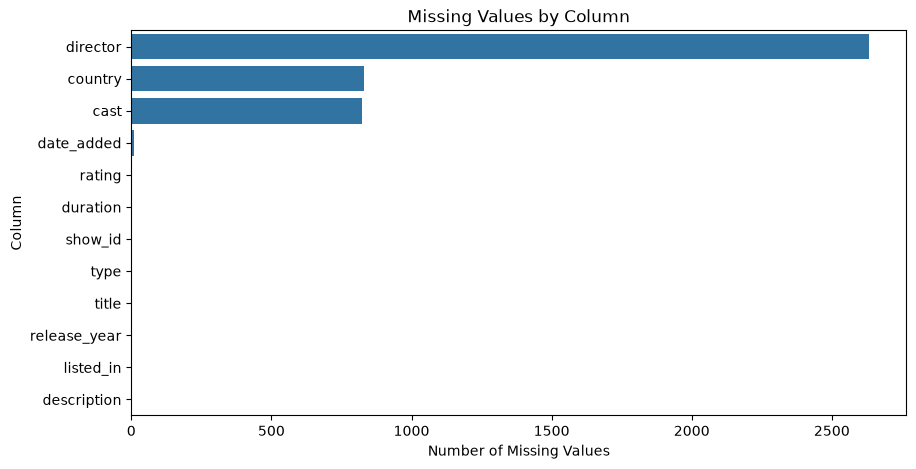

In [11]:
plt.figure(figsize=(10, 5))

missing = df.isnull().sum().sort_values(ascending=False)

sns.barplot(
    x=missing.values,
    y=missing.index
)

plt.title("Missing Values by Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Column")

plt.show()

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.isnull().sum()


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [14]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Unknown")
df["duration"] = df["duration"].fillna("Unknown")

In [15]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64

In [16]:
df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

In [17]:
df.dtypes

show_id                    str
type                       str
title                      str
director                   str
cast                       str
country                    str
date_added      datetime64[us]
release_year             int64
rating                     str
duration                   str
listed_in                  str
description                str
dtype: object

In [18]:
df["year_added"] = df["date_added"].dt.year

In [19]:
df["month_added"] = df["date_added"].dt.month_name()

In [20]:
df[["date_added", "year_added", "month_added"]].head(10)

,date_added,year_added,month_added
0,2021-09-25,2021.0,September
1,2021-09-24,2021.0,September
2,2021-09-24,2021.0,September
3,2021-09-24,2021.0,September
4,2021-09-24,2021.0,September
5,2021-09-24,2021.0,September
6,2021-09-24,2021.0,September
7,2021-09-24,2021.0,September
8,2021-09-24,2021.0,September
9,2021-09-24,2021.0,September


In [21]:
df.shape

(8807, 14)

In [22]:
year_added
month_added

NameError: name 'year_added' is not defined

In [23]:
df[["date_added", "year_added", "month_added"]].head(10)

,date_added,year_added,month_added
0,2021-09-25,2021.0,September
1,2021-09-24,2021.0,September
2,2021-09-24,2021.0,September
3,2021-09-24,2021.0,September
4,2021-09-24,2021.0,September
5,2021-09-24,2021.0,September
6,2021-09-24,2021.0,September
7,2021-09-24,2021.0,September
8,2021-09-24,2021.0,September
9,2021-09-24,2021.0,September


In [24]:
df.dtypes

show_id                    str
type                       str
title                      str
director                   str
cast                       str
country                    str
date_added      datetime64[us]
release_year             int64
rating                     str
duration                   str
listed_in                  str
description                str
year_added             float64
month_added                str
dtype: object

In [25]:
df.to_csv("netflix_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [ ]:
## 1. Movies vs TV Shows

This analysis compares the distribution of Movies and TV Shows
available on Netflix.

In [26]:
content_type = df["type"].value_counts()

content_type

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [27]:
content_percentage = (
    df["type"].value_counts(normalize=True) * 100
).round(2)

content_percentage

type
Movie      69.62
TV Show    30.38
Name: proportion, dtype: float64

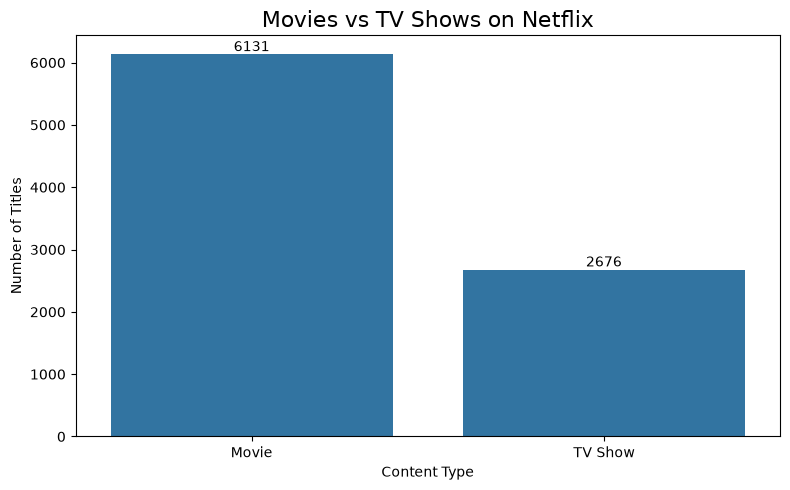

In [28]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="type"
)

plt.title("Movies vs TV Shows on Netflix", fontsize=16)
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

## 2. Netflix Content Added Over Time

This analysis examines the number of titles added to Netflix each year
to identify trends in Netflix's content acquisition.

In [30]:
content_added = (
    df["year_added"]
    .value_counts()
    .sort_index()
)

content_added

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64

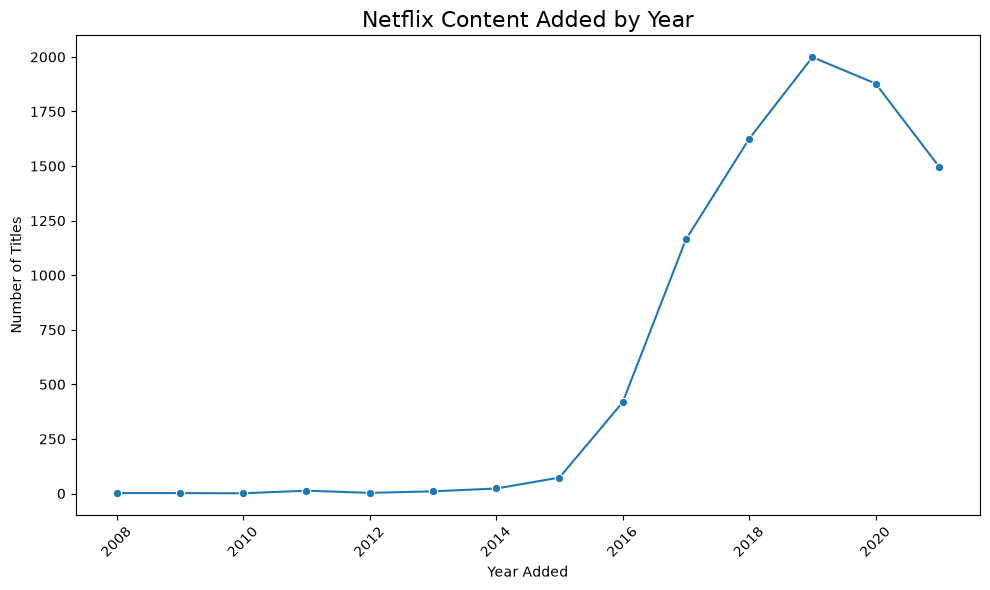

In [31]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    x=content_added.index,
    y=content_added.values,
    marker="o"
)

plt.title("Netflix Content Added by Year", fontsize=16)
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [32]:
peak_year = content_added.idxmax()
peak_count = content_added.max()

print("Peak Year:", int(peak_year))
print("Titles Added:", peak_count)

Peak Year: 2019
Titles Added: 1999


## 2. Netflix Content Added Over Time

This analysis examines the number of titles added to Netflix each year.

In [33]:
content_added = df["year_added"].value_counts().sort_index()

### Business Insight

Netflix added the highest number of titles in 2019, with 1,999 titles
added to the platform. This indicates that 2019 was a particularly
active year for Netflix's content expansion in the analyzed dataset.

## 3. Content Distribution by Release Year

This analysis examines the distribution of Netflix titles based on
their original release year to identify the periods with the highest
concentration of content.

In [34]:
release_year_counts = (
    df["release_year"]
    .value_counts()
    .sort_index()
)

release_year_counts.tail(20)

release_year
2002      51
2003      61
2004      64
2005      80
2006      96
2007      88
2008     136
2009     152
2010     194
2011     185
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64

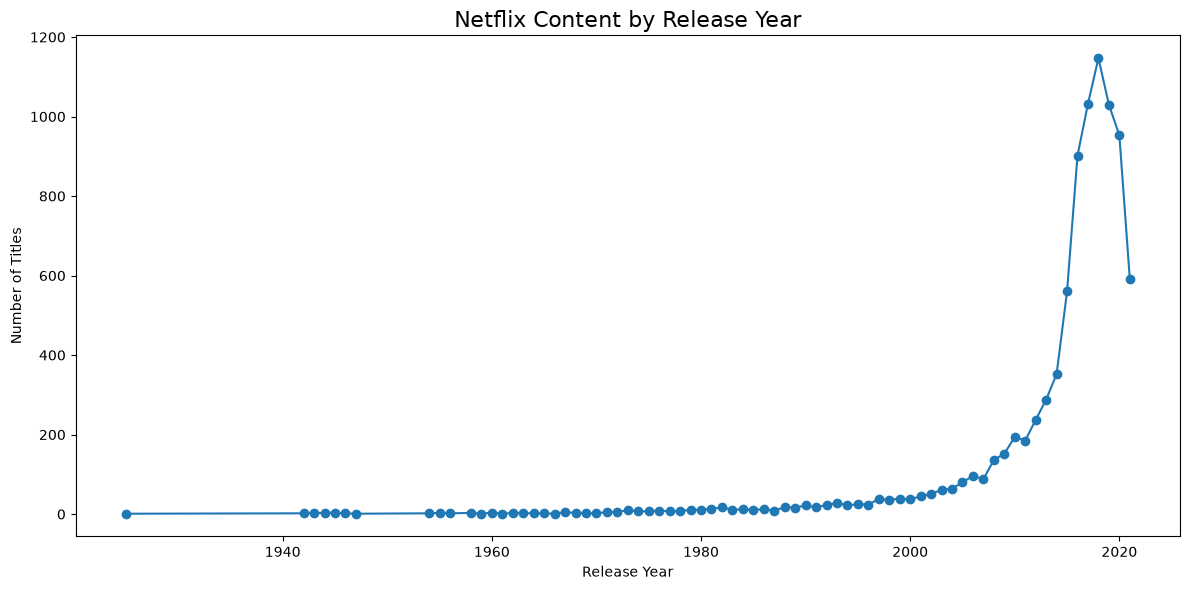

In [35]:
plt.figure(figsize=(12, 6))

plt.plot(
    release_year_counts.index,
    release_year_counts.values,
    marker="o"
)

plt.title("Netflix Content by Release Year", fontsize=16)
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()

In [36]:
peak_release_year = release_year_counts.idxmax()
peak_release_count = release_year_counts.max()

print("Peak Release Year:", peak_release_year)
print("Number of Titles:", peak_release_count)

Peak Release Year: 2018
Number of Titles: 1147


In [37]:
release_year_counts.sort_values(
    ascending=False
).head(10)

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64

In [38]:
print("Peak Release Year:", peak_release_year)
print("Number of Titles:", peak_release_count)

Peak Release Year: 2018
Number of Titles: 1147


### Business Insight

The year 2018 had the highest number of titles in the dataset, with
1,147 titles released during the year. This indicates that 2018
represents a significant concentration of Netflix content in the
analyzed catalog.

## 4. Netflix Content Ratings

This analysis examines the distribution of content ratings on Netflix
to understand the audience categories represented in the catalog.

In [39]:
rating_counts = df["rating"].value_counts()

rating_counts

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [40]:
rating_counts.head(10)


rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

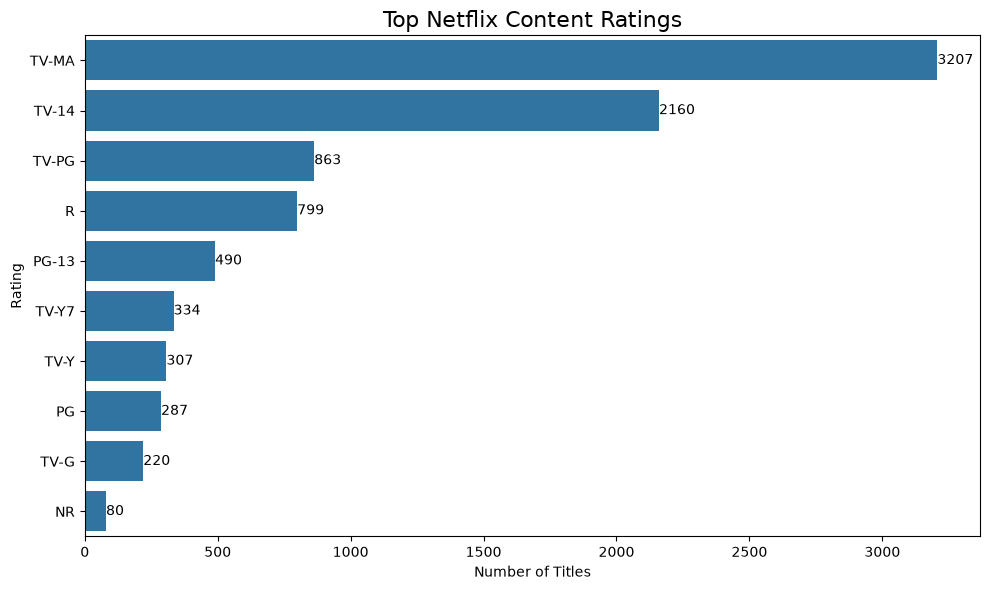

In [41]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=rating_counts.head(10).values,
    y=rating_counts.head(10).index
)

plt.title("Top Netflix Content Ratings", fontsize=16)
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [42]:
top_rating = rating_counts.idxmax()
top_rating_count = rating_counts.max()

print("Most Common Rating:", top_rating)
print("Number of Titles:", top_rating_count)

Most Common Rating: TV-MA
Number of Titles: 3207


In [43]:
top_rating_percentage = (
    top_rating_count / len(df) * 100
)

print(
    f"{top_rating} accounts for "
    f"{top_rating_percentage:.2f}% of the Netflix catalog."
)

TV-MA accounts for 36.41% of the Netflix catalog.


### Business Insight

TV-MA is the most common content rating in the Netflix catalog,
with 3,207 titles, representing approximately 36.41% of all titles
in the dataset. This indicates that mature-audience content makes
up a significant portion of Netflix's catalog.

## 5. Genre Analysis

This analysis identifies the most common genres in the Netflix
content catalog and helps understand the types of content most
frequently available on the platform.

In [44]:
genres = df["listed_in"].str.split(", ").explode()

genre_counts = genres.value_counts()

genre_counts.head(15)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
TV Comedies                  581
Thrillers                    577
Crime TV Shows               470
Kids' TV                     451
Docuseries                   395
Name: count, dtype: int64

In [45]:
top_genres = genre_counts.head(10)

top_genres

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

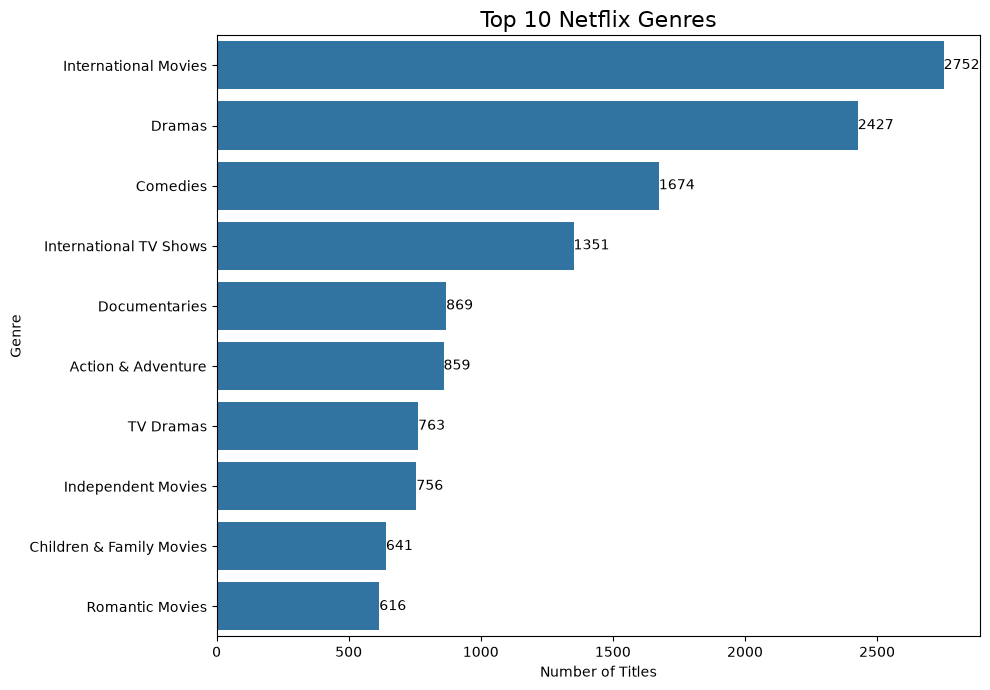

In [46]:
plt.figure(figsize=(10, 7))

ax = sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Netflix Genres", fontsize=16)
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [47]:
top_genre = genre_counts.idxmax()
top_genre_count = genre_counts.max()

print("Most Common Genre:", top_genre)
print("Number of Titles:", top_genre_count)

Most Common Genre: International Movies
Number of Titles: 2752


In [48]:
top_genre_percentage = (
    top_genre_count / len(df) * 100
)

print(
    f"{top_genre} appears in approximately "
    f"{top_genre_percentage:.2f}% of the Netflix titles."
)

International Movies appears in approximately 31.25% of the Netflix titles.


In [49]:
print("Most Common Genre:", top_genre)
print("Number of Titles:", top_genre_count)

Most Common Genre: International Movies
Number of Titles: 2752


### Business Insight

International Movies is the most frequently listed genre in the
Netflix catalog, appearing in 2,752 titles (approximately 31.25% of
the dataset). This highlights the significant presence of
international content in Netflix's catalog.

## 6. Country-wise Content Analysis

This analysis examines the countries associated with Netflix titles
to identify the major contributors to the platform's content catalog.

In [50]:
countries = df["country"].str.split(", ").explode()

country_counts = countries.value_counts()

country_counts.head(15)

country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
China              162
Australia          160
Egypt              117
Turkey             113
Name: count, dtype: int64

In [51]:
top_countries = country_counts.head(10)

top_countries

country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64

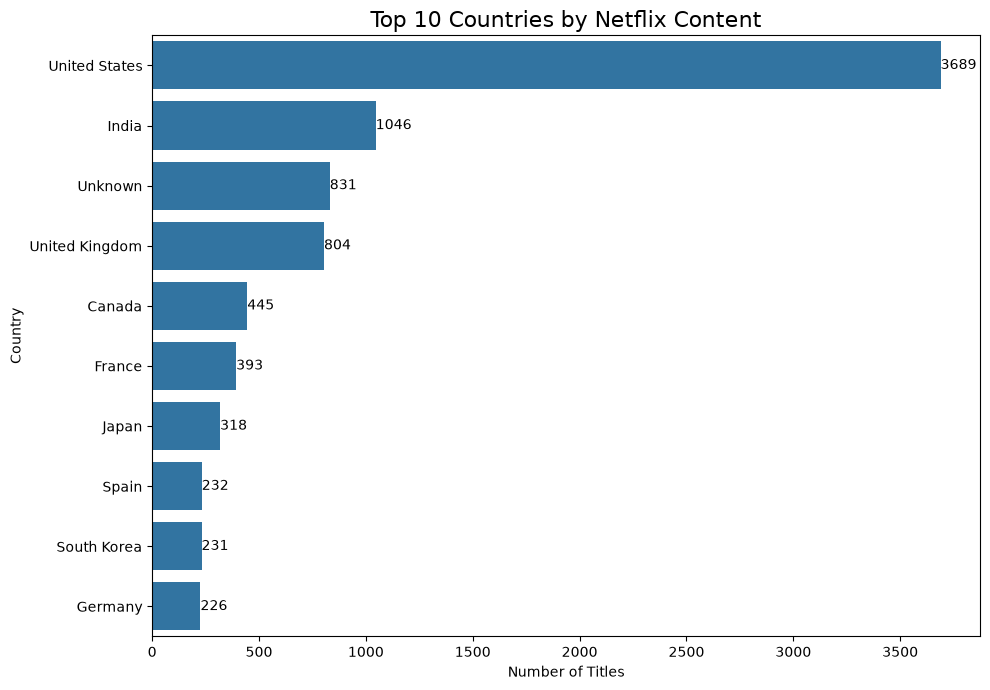

In [52]:
plt.figure(figsize=(10, 7))

ax = sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries by Netflix Content", fontsize=16)
plt.xlabel("Number of Titles")
plt.ylabel("Country")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [53]:
top_country = country_counts.idxmax()
top_country_count = country_counts.max()

print("Top Country:", top_country)
print("Number of Titles:", top_country_count)

Top Country: United States
Number of Titles: 3689


In [54]:
top_country_percentage = (
    top_country_count / len(df) * 100
)

print(
    f"{top_country} is associated with approximately "
    f"{top_country_percentage:.2f}% of Netflix titles."
)

United States is associated with approximately 41.89% of Netflix titles.


In [55]:
print("Top Country:", top_country)
print("Number of Titles:", top_country_count)

Top Country: United States
Number of Titles: 3689


### Business Insight

The United States is the country most frequently associated with
Netflix titles, with 3,689 titles, representing approximately
41.89% of the dataset. This highlights the strong contribution of
US-produced content to the Netflix catalog.

## 7. Movie Duration Analysis

This analysis examines the duration of movies available on Netflix
and identifies the typical length of movies in the catalog.

In [56]:
movies = df[df["type"] == "Movie"].copy()

print("Total Movies:", len(movies))

Total Movies: 6131


In [57]:
movies["duration_minutes"] = (
    movies["duration"]
    .str.extract(r"(\d+)")
    .astype(float)
)

In [58]:
movies[["title", "duration", "duration_minutes"]].head(10)

,title,duration,duration_minutes
0,Dick Johnson Is Dead,90 min,90.0
6,My Little Pony: A New Generation,91 min,91.0
7,Sankofa,125 min,125.0
9,The Starling,104 min,104.0
12,Je Suis Karl,127 min,127.0
13,Confessions of an Invisible Girl,91 min,91.0
16,Europe's Most Dangerous Man: Otto Skorzeny in ...,67 min,67.0
18,Intrusion,94 min,94.0
22,Avvai Shanmughi,161 min,161.0
23,Go! Go! Cory Carson: Chrissy Takes the Wheel,61 min,61.0


In [59]:
movies["duration_minutes"].describe()

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_minutes, dtype: float64

In [60]:
average_duration = movies["duration_minutes"].mean()
median_duration = movies["duration_minutes"].median()

print(f"Average Movie Duration: {average_duration:.2f} minutes")
print(f"Median Movie Duration: {median_duration:.2f} minutes")

Average Movie Duration: 99.58 minutes
Median Movie Duration: 98.00 minutes


In [61]:
shortest_movie = movies.loc[
    movies["duration_minutes"].idxmin(),
    ["title", "duration"]
]

longest_movie = movies.loc[
    movies["duration_minutes"].idxmax(),
    ["title", "duration"]
]

print("Shortest Movie:")
print(shortest_movie)

print("\nLongest Movie:")
print(longest_movie)

Shortest Movie:
title       Silent
duration     3 min
Name: 3777, dtype: str

Longest Movie:
title       Black Mirror: Bandersnatch
duration                       312 min
Name: 4253, dtype: str


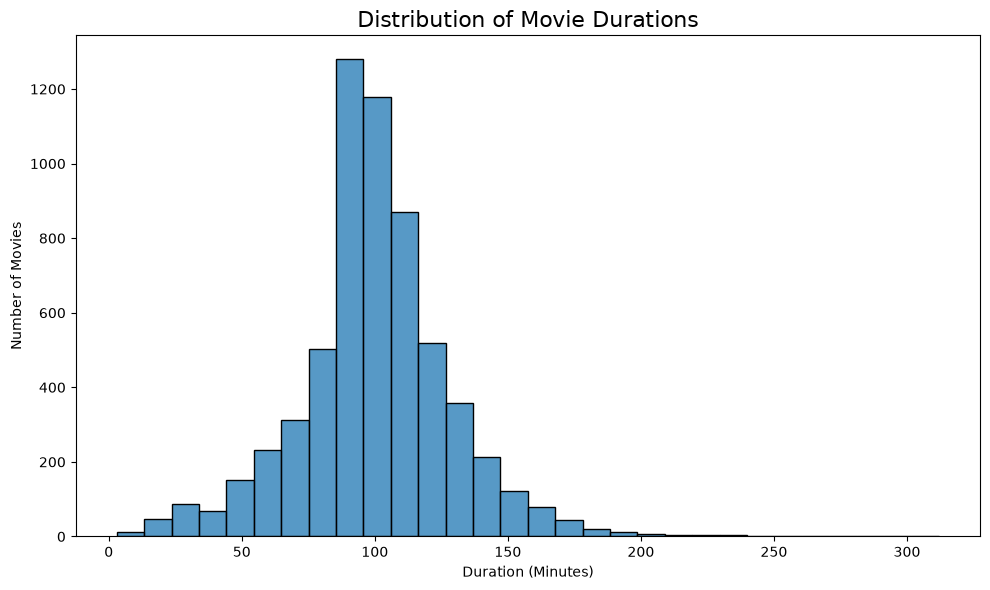

In [62]:
plt.figure(figsize=(10, 6))

sns.histplot(
    movies["duration_minutes"].dropna(),
    bins=30
)

plt.title("Distribution of Movie Durations", fontsize=16)
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.tight_layout()
plt.show()

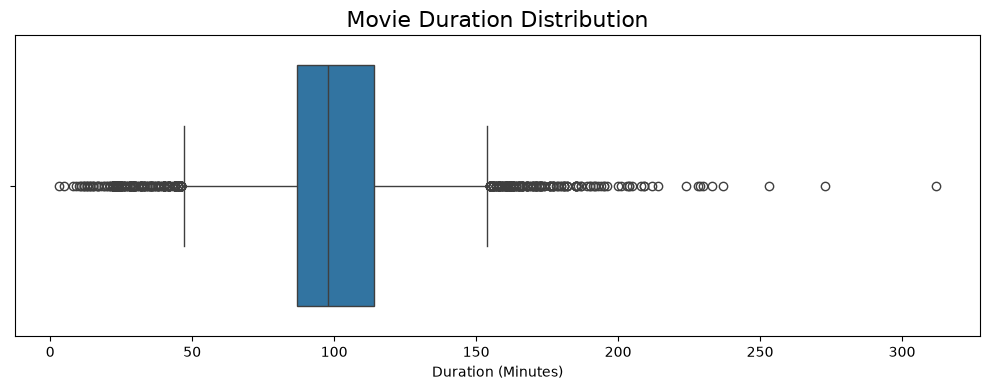

In [63]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=movies["duration_minutes"].dropna()
)

plt.title("Movie Duration Distribution", fontsize=16)
plt.xlabel("Duration (Minutes)")

plt.tight_layout()
plt.show()

In [64]:
print(f"Average Movie Duration: {average_duration:.2f} minutes")
print(f"Median Movie Duration: {median_duration:.2f} minutes")

Average Movie Duration: 99.58 minutes
Median Movie Duration: 98.00 minutes


## 8. TV Show Season Analysis

This analysis examines the number of seasons in Netflix TV Shows
to understand the typical length of TV content available on the platform.

In [65]:
tv_shows = df[df["type"] == "TV Show"].copy()

print("Total TV Shows:", len(tv_shows))

Total TV Shows: 2676


In [66]:
tv_shows = df[df["type"] == "TV Show"].copy()

print("Total TV Shows:", len(tv_shows))

Total TV Shows: 2676


In [67]:
tv_shows["seasons"] = (
    tv_shows["duration"]
    .str.extract(r"(\d+)")
    .astype(float)
)

In [68]:
tv_shows[["title", "duration", "seasons"]].head(10)

,title,duration,seasons
1,Blood & Water,2 Seasons,2.0
2,Ganglands,1 Season,1.0
3,Jailbirds New Orleans,1 Season,1.0
4,Kota Factory,2 Seasons,2.0
5,Midnight Mass,1 Season,1.0
8,The Great British Baking Show,9 Seasons,9.0
10,"Vendetta: Truth, Lies and The Mafia",1 Season,1.0
11,Bangkok Breaking,1 Season,1.0
14,Crime Stories: India Detectives,1 Season,1.0
15,Dear White People,4 Seasons,4.0


In [69]:
season_counts = (
    tv_shows["seasons"]
    .value_counts()
    .sort_index()
)

season_counts

seasons
1.0     1793
2.0      425
3.0      199
4.0       95
5.0       65
6.0       33
7.0       23
8.0       17
9.0        9
10.0       7
11.0       2
12.0       2
13.0       3
15.0       2
17.0       1
Name: count, dtype: int64

In [70]:
most_common_seasons = season_counts.idxmax()
most_common_season_count = season_counts.max()

print("Most Common Number of Seasons:", int(most_common_seasons))
print("Number of TV Shows:", most_common_season_count)

Most Common Number of Seasons: 1
Number of TV Shows: 1793


In [71]:
season_percentage = (
    most_common_season_count / len(tv_shows) * 100
)

print(
    f"TV Shows with {int(most_common_seasons)} season(s) "
    f"represent approximately {season_percentage:.2f}% "
    f"of all Netflix TV Shows."
)

TV Shows with 1 season(s) represent approximately 67.00% of all Netflix TV Shows.


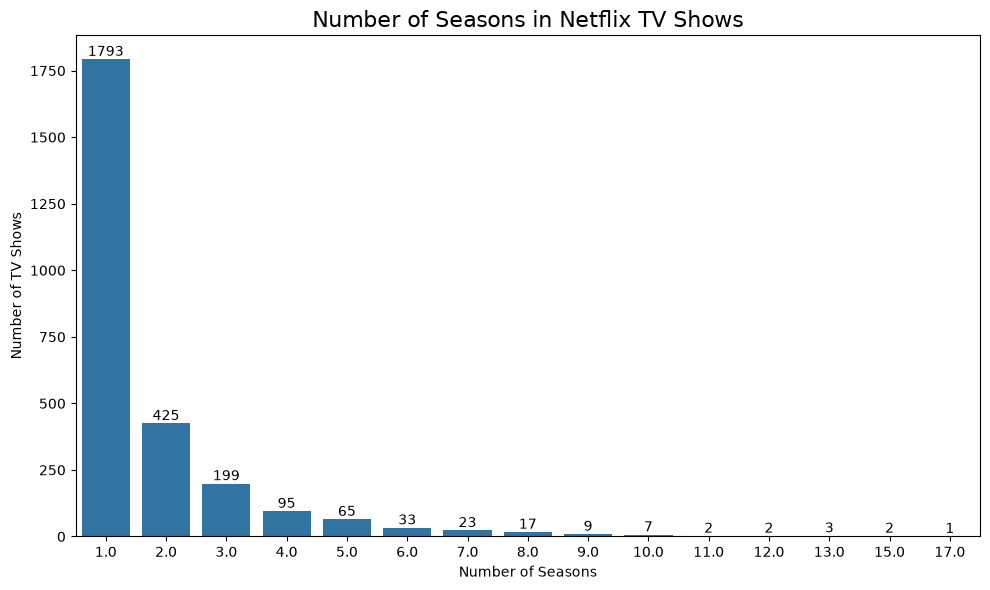

In [72]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=season_counts.index,
    y=season_counts.values
)

plt.title("Number of Seasons in Netflix TV Shows", fontsize=16)
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [73]:
print("Most Common Number of Seasons:", int(most_common_seasons))
print("Number of TV Shows:", most_common_season_count)

Most Common Number of Seasons: 1
Number of TV Shows: 1793


## 9. Movies vs TV Shows by Release Year

This analysis compares the number of Movies and TV Shows across
different release years to identify changes in the composition
of Netflix's content catalog.

In [74]:
type_year = pd.crosstab(
    df["release_year"],
    df["type"]
)

type_year.tail(20)

type,Movie,TV Show
release_year,,
2002,44,7
2003,51,10
2004,55,9
2005,67,13
2006,82,14
2007,74,14
2008,113,23
2009,118,34
2010,154,40


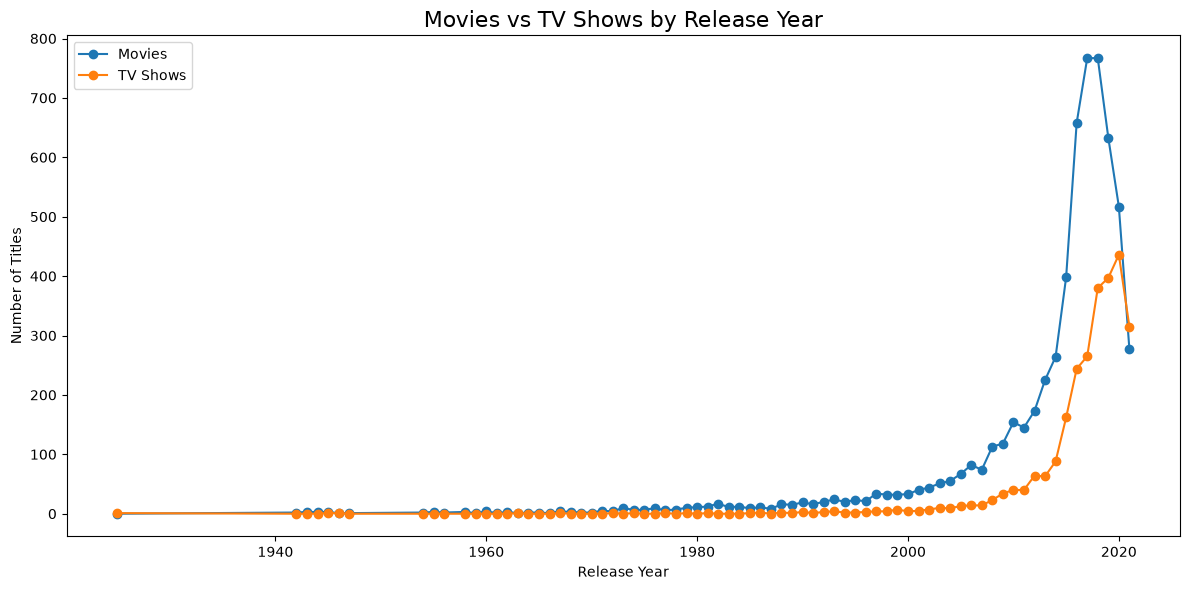

In [75]:
plt.figure(figsize=(12, 6))

plt.plot(
    type_year.index,
    type_year["Movie"],
    marker="o",
    label="Movies"
)

plt.plot(
    type_year.index,
    type_year["TV Show"],
    marker="o",
    label="TV Shows"
)

plt.title("Movies vs TV Shows by Release Year", fontsize=16)
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.legend()
plt.tight_layout()
plt.show()

In [76]:
recent_type_year = type_year[
    type_year.index >= 2000
]

recent_type_year.tail(20)

type,Movie,TV Show
release_year,,
2002,44,7
2003,51,10
2004,55,9
2005,67,13
2006,82,14
2007,74,14
2008,113,23
2009,118,34
2010,154,40


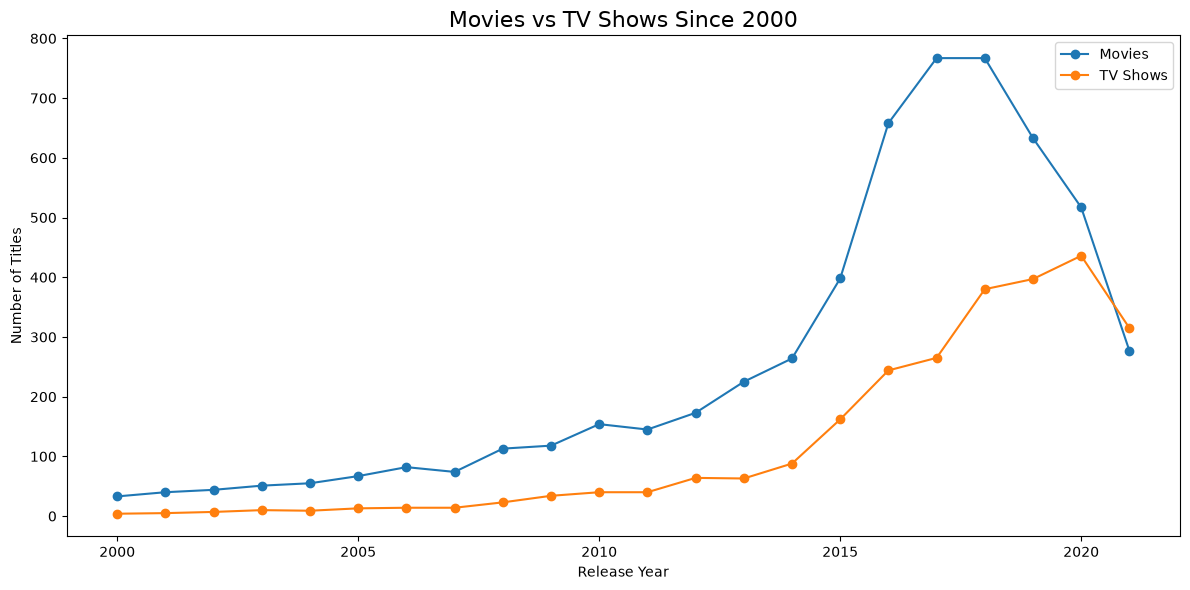

In [77]:
plt.figure(figsize=(12, 6))

plt.plot(
    recent_type_year.index,
    recent_type_year["Movie"],
    marker="o",
    label="Movies"
)

plt.plot(
    recent_type_year.index,
    recent_type_year["TV Show"],
    marker="o",
    label="TV Shows"
)

plt.title("Movies vs TV Shows Since 2000", fontsize=16)
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.legend()
plt.tight_layout()
plt.show()

In [78]:
movie_peak_year = type_year["Movie"].idxmax()
movie_peak_count = type_year["Movie"].max()

tv_peak_year = type_year["TV Show"].idxmax()
tv_peak_count = type_year["TV Show"].max()

print("Peak Movie Release Year:", movie_peak_year)
print("Movies Released:", movie_peak_count)

print("\nPeak TV Show Release Year:", tv_peak_year)
print("TV Shows Released:", tv_peak_count)

Peak Movie Release Year: 2017
Movies Released: 767

Peak TV Show Release Year: 2020
TV Shows Released: 436


In [79]:
print("Peak Movie Release Year:", movie_peak_year)
print("Movies Released:", movie_peak_count)

print("\nPeak TV Show Release Year:", tv_peak_year)
print("TV Shows Released:", tv_peak_count)

Peak Movie Release Year: 2017
Movies Released: 767

Peak TV Show Release Year: 2020
TV Shows Released: 436


### Business Insight

Movies reached their highest representation in the dataset in 2017,
with 767 titles released. TV Shows reached their highest
representation in 2020, with 436 titles released.

This comparison shows that the peak release periods differ between
Movies and TV Shows, highlighting different patterns in the
availability of each content type.

## 10. Director Analysis

This analysis identifies the directors associated with the highest
number of titles in the Netflix catalog.

In [80]:
director_counts = (
    df[df["director"] != "Unknown"]["director"]
    .value_counts()
)

director_counts.head(15)

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Youssef Chahine           12
Martin Scorsese           12
Jay Chapman               12
Steven Spielberg          11
Don Michael Paul          10
David Dhawan               9
Quentin Tarantino          8
Robert Rodriguez           8
Yılmaz Erdoğan             8
Name: count, dtype: int64

In [81]:
top_director = director_counts.idxmax()
top_director_count = director_counts.max()

print("Top Director:", top_director)
print("Number of Titles:", top_director_count)

Top Director: Rajiv Chilaka
Number of Titles: 19


plt.figure(figsize=(10, 7))

top_directors = director_counts.head(10)

ax = sns.barplot(
    x=top_directors.values,
    y=top_directors.index
)

plt.title("Top 10 Directors by Number of Netflix Titles", fontsize=16)
plt.xlabel("Number of Titles")
plt.ylabel("Director")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [83]:
top_directors_df = pd.DataFrame({
    "Director": top_directors.index,
    "Number of Titles": top_directors.values
})

top_directors_df

,Director,Number of Titles
0,Rajiv Chilaka,19
1,"Raúl Campos, Jan Suter",18
2,Suhas Kadav,16
3,Marcus Raboy,16
4,Jay Karas,14
5,Cathy Garcia-Molina,13
6,Youssef Chahine,12
7,Martin Scorsese,12
8,Jay Chapman,12
9,Steven Spielberg,11


### Business Insight

Rajiv Chilaka is the director associated with the highest number of
titles in the Netflix dataset, with 19 titles. Raul Campos and Jan
Suter follow with 18 titles, while Suhas Kadav and Marcus Raboy are
associated with 16 titles each.

# Final Business Insights

### Content Distribution
The Netflix catalog contains both Movies and TV Shows, with Movies
representing the larger share of the available content.

### Content Acquisition
2019 was the peak year for Netflix content additions, with 1,999
titles added to the platform.

### Release Trends
2018 had the highest number of titles by original release year,
with 1,147 titles.

### Ratings
TV-MA was the most common rating, accounting for 3,207 titles
(36.41% of the dataset).

### Genres
International Movies was the most frequently listed genre, appearing
in 2,752 titles.

### Countries
The United States was the country most frequently associated with
Netflix titles, with 3,689 titles (41.89%).

### Movie Duration
Movies had an average duration of 99.58 minutes and a median duration
of 98 minutes.

### TV Shows
TV Shows with one season were the most common, with 1,793 titles.

### Release Type Trends
The highest number of Movies occurred in 2017 with 767 titles,
while TV Shows peaked in 2020 with 436 titles.

### Directors
Rajiv Chilaka was associated with the highest number of titles,
with 19 titles in the dataset.

In [85]:
df.shape

(8807, 14)

In [86]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,September
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,September
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,September
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,September


In [87]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         0
listed_in        0
description      0
year_added      98
month_added     98
dtype: int64

In [88]:
df.to_csv("netflix_cleaned.csv", index=False)

print("Final cleaned dataset exported successfully!")

Final cleaned dataset exported successfully!


In [89]:
original_df = pd.read_csv("netflix_titles.csv")

In [90]:
original_df["date_added"] = pd.to_datetime(
    original_df["date_added"],
    format="%B %d, %Y",
    errors="coerce"
)

In [91]:
print("Missing dates:", original_df["date_added"].isnull().sum())

Missing dates: 98


In [94]:
raw_df = pd.read_csv("netflix_titles.csv")

raw_df["date_added"].isnull().sum()

np.int64(10)

In [93]:
raw_df.loc[
    raw_df["date_added"].notna(),
    "date_added"
].head(20)

0     September 25, 2021
1     September 24, 2021
2     September 24, 2021
3     September 24, 2021
4     September 24, 2021
5     September 24, 2021
6     September 24, 2021
7     September 24, 2021
8     September 24, 2021
9     September 24, 2021
10    September 24, 2021
11    September 23, 2021
12    September 23, 2021
13    September 22, 2021
14    September 22, 2021
15    September 22, 2021
16    September 22, 2021
17    September 22, 2021
18    September 22, 2021
19    September 22, 2021
Name: date_added, dtype: str

In [95]:
raw_df.loc[
    pd.to_datetime(
        raw_df["date_added"],
        errors="coerce"
    ).isna() & raw_df["date_added"].notna(),
    "date_added"
].head(20)

6079        August 4, 2017
6177     December 23, 2018
6213     December 15, 2018
6279          July 1, 2017
6304         July 26, 2019
6318          May 26, 2016
6357      November 1, 2019
6361      December 2, 2017
6368        March 15, 2019
6393       October 1, 2019
6451     December 15, 2017
6456          July 1, 2017
6457        August 4, 2017
6460         April 4, 2017
6519     December 28, 2016
6549        March 31, 2018
6560      February 1, 2019
6603       January 1, 2018
6671          July 1, 2017
6678     February 24, 2018
Name: date_added, dtype: str

In [96]:
test_dates = pd.to_datetime(
    raw_df["date_added"],
    format="mixed",
    errors="coerce"
)

print("Original missing:", raw_df["date_added"].isna().sum())
print("After parsing:", test_dates.isna().sum())

Original missing: 10
After parsing: 10


In [97]:
df["date_added"] = test_dates

df["year_added"] = df["date_added"].dt.year

df["month_added"] = df["date_added"].dt.month_name()

In [98]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
year_added      10
month_added     10
dtype: int64

In [99]:
df.to_csv("netflix_cleaned.csv", index=False)

print("Final cleaned dataset exported successfully!")

Final cleaned dataset exported successfully!


In [100]:
import os

print(os.path.exists("netflix_cleaned.csv"))

True
